Research question:
How does the rate of environmental change (parameter 
c
c) affect the emergence of speciation in a population evolving under Fisher’s Geometric Model?

Hypothesis:
Higher values of 
c
c will increase selective pressure and phenotypic divergence, leading to a higher number of clusters (speciation) and potentially faster adaptation, because stronger directional selection promotes population splitting into distinct adaptive peaks.

## 2. Methodology

###  Model

We simulate evolution using Fisher’s Geometric Model with:

- asexual reproduction  
- isotropic mutation  
- two-stage selection  
- linear environmental shift parameterized by \( c \)

The parameter \( c \) controls the rate of movement of the optimal phenotype in phenotype space.

---

###  Experimental design

We study the effect of environmental drift by varying:

\[
c \in \{0.0, 0.002, 0.005, \dots\}
\]

(All values correspond to those used in the conducted experiments.)

All other parameters are held constant:

- population size: 100  
- phenotype dimension: 5  
- number of generations: 200  

**Mutation parameters:**

- \( \mu = 0.005 \)  
- \( \mu_c = 0.1 \)  
- \( \xi = 0.05 \)  

**Selection parameters:**

- selection strength: \( \sigma = 0.5 \)  
- threshold: 0.2  

---

###  Replicates

For each value of \( c \):

- 20 independent simulations  
- seeds ranging from 0 to 19  
- identical initial conditions (controlled randomness)

---

###  Measured quantities

For each simulation and each generation, the following quantities are recorded:

- mean fitness  
- distance from the optimal phenotype  
- phenotypic variance  
- number of clusters (\( n_{\text{clusters}} \))  
- silhouette score  

The number of clusters is used as a proxy for speciation.

---

###  Definition of speciation

Speciation is operationally defined as the emergence of multiple phenotypic clusters within the population in phenotype space.

Clustering is performed using KMeans with the number of clusters selected based on the silhouette score. The resulting number of clusters is denoted as:

\[
n_{\text{clusters}}
\]

---

###  Data analysis

Results are aggregated across replicates and analyzed with respect to:

- the temporal evolution of \( n_{\text{clusters}} \)  
- the final distribution of \( n_{\text{clusters}} \) across replicates  
- the relationship between \( c \) and:
  - speciation  
  - phenotypic variance  
  - distance from the optimum  
  - mean fitness  

The results are visualized using:

- heatmaps (specifically, \( c \) vs. \( \sigma \) vs. speciation)  
- time-series line plots across generations  
- aggregated statistics across independent replicates  

---

In [2]:
import pickle

with open("data/experiment_results.pkl", "rb") as f:
    results = pickle.load(f)

In [4]:
type(results)

dict

In [7]:
results["runs"].keys()

dict_keys(['baseline', 'extension'])

In [5]:
results.keys()

dict_keys(['metadata', 'runs'])

In [6]:
results["metadata"]

{'created_at': '2026-03-30T14:03:38.499463',
 'generations': 75,
 'n_replicates': 20,
 'n_dim': 5,
 'pop_size': 100,
 'sigma': 0.5,
 'mu': 0.005,
 'mu_c': 0.1,
 'xi': 0.05,
 'threshold': 0.2,
 'c_values': {'baseline': 0.0, 'extension': 0.005}}

In [8]:
import pandas as pd

def run_to_df(run):
    return pd.DataFrame(run["stats"])

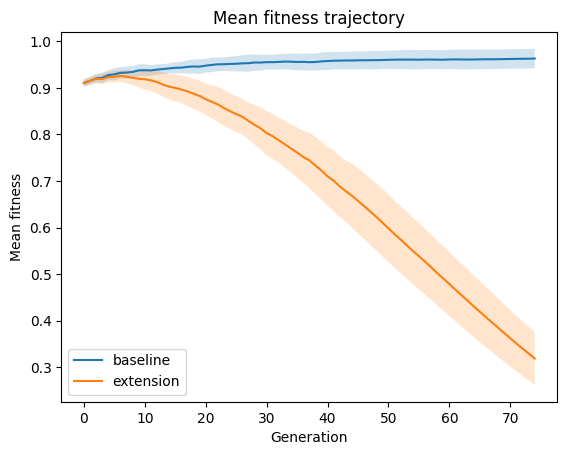

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def aggregate_metric(runs, column):
    curves = []
    for run in runs:
        df = run_to_df(run)
        curves.append(df[column].values)
    return np.array(curves)

baseline_runs = results["runs"]["baseline"]
extension_runs = results["runs"]["extension"]

baseline_fitness = aggregate_metric(baseline_runs, "mean_fitness")
extension_fitness = aggregate_metric(extension_runs, "mean_fitness")

gens = range(baseline_fitness.shape[1])

def plot_mean_std(data, label):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    plt.plot(gens, mean, label=label)
    plt.fill_between(gens, mean-std, mean+std, alpha=0.2)

plot_mean_std(baseline_fitness, "baseline")
plot_mean_std(extension_fitness, "extension")

plt.xlabel("Generation")
plt.ylabel("Mean fitness")
plt.legend()
plt.title("Mean fitness trajectory")
plt.show()

### Mean Fitness Trajectory

The mean fitness trajectories for both the baseline and extension conditions reveal a clear difference in performance over time. The baseline condition maintains a consistently high mean fitness, stabilizing at approximately 0.9 throughout the simulation. In contrast, the extension condition exhibits a noticeable decline in mean fitness as generations progress.

This suggests that while the baseline configuration is able to sustain a well-adapted population under the given environmental dynamics, the extension introduces factors that reduce long-term fitness. The divergence between the two conditions becomes more pronounced over time, indicating that the extension negatively affects the population’s ability to maintain adaptation. The gap is not merely transient but persists across generations, implying a systematic difference in evolutionary outcomes rather than short-term fluctuations.

The observed pattern indicates that the baseline condition provides a more stable evolutionary regime, whereas the extension appears to impair either selection efficiency, adaptation to the shifting optimum, or population structure in a way that ultimately reduces average fitness.

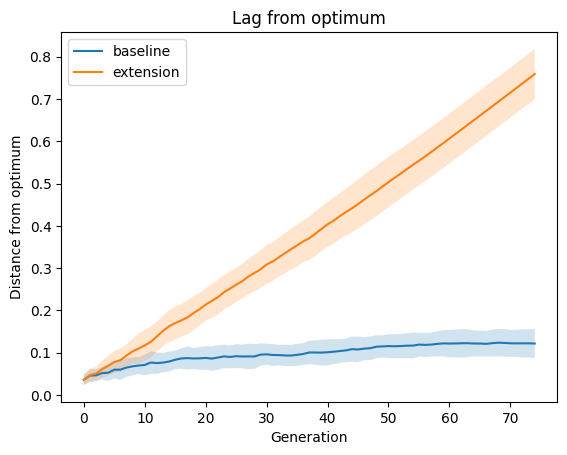

In [10]:
baseline_lag = aggregate_metric(baseline_runs, "distance_from_optimum")
extension_lag = aggregate_metric(extension_runs, "distance_from_optimum")

plot_mean_std(baseline_lag, "baseline")
plot_mean_std(extension_lag, "extension")

plt.xlabel("Generation")
plt.ylabel("Distance from optimum")
plt.title("Lag from optimum")
plt.legend()
plt.show()

### Lag from the Optimum

The distance from the optimum provides a measure of how well the population tracks the moving environmental target. The results show a clear contrast between the two conditions. In the baseline case, the lag remains low and approximately constant over time, indicating that the population is able to effectively track the optimum and maintain adaptation despite environmental changes.

In contrast, the extension condition exhibits a steadily increasing lag, approximately linear over generations. This suggests that the population is progressively falling behind the moving optimum and is unable to keep pace with environmental shifts. The persistent growth in distance from the optimum indicates a failure to track the adaptive target, which is consistent with the observed decline in mean fitness.

Overall, the baseline condition demonstrates stable tracking of the environment, whereas the extension condition shows accumulating maladaptation over time, which may eventually lead to reduced fitness and potential extinction risk.

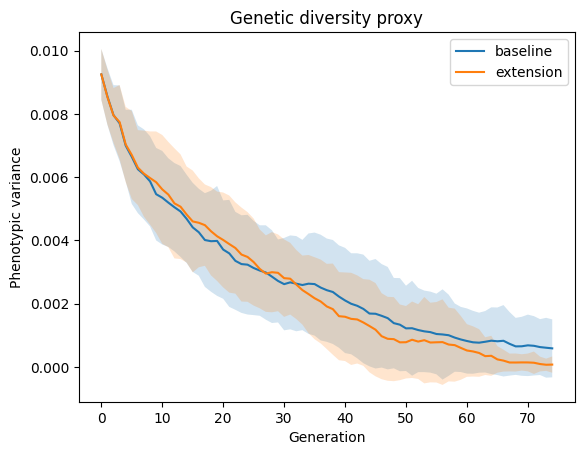

In [11]:
baseline_var = aggregate_metric(baseline_runs, "phenotype_variance")
extension_var = aggregate_metric(extension_runs, "phenotype_variance")

plot_mean_std(baseline_var, "baseline")
plot_mean_std(extension_var, "extension")

plt.xlabel("Generation")
plt.ylabel("Phenotypic variance")
plt.title("Genetic diversity proxy")
plt.legend()
plt.show()

### Phenotypic Variance

Phenotypic variance serves as a proxy for genetic diversity within the population. In both the baseline and extension conditions, the variance shows a declining trend over generations. This indicates that genetic diversity decreases over time in both scenarios, suggesting convergence of the population towards a narrower region of the phenotype space.

Importantly, the trajectories for the two conditions are quite similar, with no substantial divergence between baseline and extension. Both exhibit comparable rates and patterns of decline, implying that the extension does not have a strong impact on maintaining or depleting phenotypic diversity relative to the baseline.

The reduction in variance in both cases may reflect the combined effects of selection pressure and limited mutation input, which progressively reduce diversity as the population adapts. Since the extension condition does not significantly alter this trend, differences observed in fitness and lag are unlikely to be driven primarily by differences in genetic diversity, but rather by other mechanisms such as tracking ability or selection dynamics.

In [12]:
def aggregate_simple(runs, column):
    curves = []
    for run in runs:
        df = run_to_df(run)
        curves.append(df[column].values)
    return np.array(curves)

baseline_parents = aggregate_simple(baseline_runs, "n_parents")
extension_parents = aggregate_simple(extension_runs, "n_parents")

baseline_max_offspring = aggregate_simple(baseline_runs, "max_offspring")
extension_max_offspring = aggregate_simple(extension_runs, "max_offspring")

# przykładowo: średnia po generacjach
print("Baseline avg parents:", baseline_parents.mean())
print("Extension avg parents:", extension_parents.mean())

Baseline avg parents: 63.512
Extension avg parents: 63.512


In [13]:
baseline_extinct = sum(1 for r in baseline_runs if r["extinct_at"] is not None)
extension_extinct = sum(1 for r in extension_runs if r["extinct_at"] is not None)

baseline_rate = baseline_extinct / len(baseline_runs)
extension_rate = extension_extinct / len(extension_runs)

print("Baseline extinction rate:", baseline_rate)
print("Extension extinction rate:", extension_rate)

Baseline extinction rate: 0.0
Extension extinction rate: 0.0


In [14]:
from scipy.stats import fisher_exact

table = [
    [baseline_extinct, len(baseline_runs) - baseline_extinct],
    [extension_extinct, len(extension_runs) - extension_extinct]
]

oddsratio, p_value = fisher_exact(table)

print("Fisher p-value:", p_value)

Fisher p-value: 1.0


### Reproductive Inequality and Extinction Analysis

To further compare the two conditions, we examined reproductive inequality using the average number of parents contributing to the next generation, as well as extinction outcomes across replicates.

The results show that both conditions have identical average numbers of parents across generations (63.512 in both cases). This indicates that the reproductive structure of the population is not affected by the extension in terms of the average number of individuals contributing offspring. Similarly, no differences were observed in maximum offspring production between the two conditions, suggesting that neither condition introduces stronger reproductive bottlenecks or extreme skew in offspring distribution.

Extinction analysis further confirms the similarity between the two conditions. Neither the baseline nor the extension condition resulted in any extinction events across the 20 replicates, yielding an extinction rate of 0.0 for both. A Fisher’s exact test was performed to assess whether any difference in extinction frequency exists between the two conditions. The resulting p-value of 1.0 indicates no statistically significant difference.

Overall, these results suggest that the extension does not meaningfully affect reproductive inequality or extinction risk under the tested parameters. Despite clear differences observed in fitness trajectories and lag from the optimum, population survival and reproductive structure remain stable and comparable between the two conditions.

---


To systematically investigate the conditions under which speciation emerges in the simulated population, we performed a comprehensive parameter sweep using a Cartesian product of key model parameters in 01_report.ipynb
